# Secret Independence with optimal control in NV-center: GRAPE, SDP 

In [2]:
import numpy as np
import cvxpy as cp 
from numpy import cos, sin, pi
import qutip
import qutip_qtrl.pulsegen as pulsegen
import qutip_qtrl.pulseoptim as cpo
from qutip import basis, identity, sigmax, sigmay, sigmaz, tensor, about, liouvillian, ket2dm, operator_to_vector, vector_to_operator, destroy, qeye, Qobj
from qutip_qip.algorithms import qft
from scipy.sparse import block_diag as sp_block_diag

import matplotlib.pyplot as plt
%matplotlib inline

## The NV-system 

Simple electronic single spin 

https://www.nature.com/articles/s41534-017-0049-8

Control hamiltonian 

$H_c = 2\pi\Omega (x(t) \sigma_x + y(t)\sigma_y)$

Drift Hamiltonian, in rotating frame with detuning $\Delta$ 

$H_d = 2\pi\Delta \sigma_z$

### Functions

In [5]:
#def plot_pulse(result):
#    final_fidelity_error = result.fid_err
#    fig1 = plt.figure()
#    ax = fig1.add_subplot(2, 1, 2)
#    ax.set_title(f"Optimized Control Sequences: fid_err = {final_fidelity_error:.8e}")
#    ax.set_xlabel("Time")
#    ax.set_ylabel("Control amplitude")
#    ax.step(
#        result.time,
#        np.hstack((result.final_amps[:, 0], result.final_amps[-1, 0])),
#        where="post",
#    )
#    plt.tight_layout()
#    plt.show()

In [6]:
## Choi application as numerics and CVXPY
#def apply_choi_np(J, rho, dA=2, dB=2):
#    """
#    E(rho) from Choi matrix J, using the convention
#    J[a1,b1,a2,b2] and
#    E(rho)[b1,b2] = sum_{a1,a2} J[a1,b1,a2,b2] rho[a1,a2].
#    """
#    J4 = J.reshape(dA, dB, dA, dB)   # (a1, b1, a2, b2)
#    R  = rho.reshape(dA, 1, dA, 1)   # (a1, 1, a2, 1)
#    E  = np.sum(J4 * R, axis=(0, 2)) # sum over a1,a2 → (b1,b2)
#    return E
#
#
#def apply_choi_cp(J, rho, dA=2, dB=2):
#    J4 = cp.reshape(J, (dA, dB, dA, dB))
#    R  = cp.reshape(rho, (dA, 1, dA, 1))
#    E  = cp.sum(cp.multiply(J4, R), axis=(0, 2))
#    return E

In [7]:
#def calc_objective(target_states, final_states, J=None):
#    K = len(target_states)
#    obj_val = 0
#    for k in range(K):
#        a_k = target_states[k]   # 2x2 numpy
#        b_k = final_states[k]   # 2x2 numpy
#        if J is None:
#            E_a_k = a_k
#        else :
#            E_a_k = apply_choi_np(J, a_k)    # 2x2
#        Delta = E_a_k - b_k
#        s = np.linalg.svd(Delta, compute_uv=False)  # singular values
#        obj_val += 0.5 * np.sum(s)
#    obj_val /= K
#    return obj_val

### Direct Sum
$ \rho = \begin{pmatrix}
\rho_1 & 0\\
0 & \rho_2
\end{pmatrix}$

$ H = \begin{pmatrix}
H_1 & 0\\
0 & H_2
\end{pmatrix}$

$ U = \begin{pmatrix}
U_1 & 0\\
0 & U_2
\end{pmatrix}$

In [9]:
def run_grape_for_det(detuning, init_statev, target_statev, U, lam, amps=None):
    """
    Run GRAPE optimisation for a given detuning and return the result object.
    """
    T2_star = 2e-6 #300 mus
    # spin-1
    Sx_1 = 0.5 * sigmax()
    Sy_1 = 0.5 * sigmay()
    Sz_1 = 0.5 * sigmaz()
    Si_1 = 0.5 * identity(2)

    # Number of qubits
    D = int(np.sqrt(np.shape(init_statev)[0]))
    #print(D)
    d = 2
    K = int(D / d)
    #print(K)

    # for K qubits
    Sx = []
    Sy = []
    if K == 1:
        Sx = Sx_1
        Sy = Sy_1
        Sz = Sz_1
        Si = Si_1
    else:
        for i in range(K):
            Sx.append(tensor(basis(K, i) * basis(K, i).dag(), Sx_1))
            Sy.append(tensor(basis(K, i) * basis(K, i).dag(), Sy_1))
        Sz = tensor(qeye(K), Sz_1)
        Si = tensor(qeye(K), Si_1)

    # drift in rotating frame
    Omega = 10e6 # 5- 15 MHz
    delta = detuning * Omega  #  can add detuning error here
    H_drift = 2.0 * pi * delta * Sz # rad / sec


    # AMPLITUDE MIS-CALIBRATION (realistic 1–5%)
    amp_error = 0.03         # 3% amplitude error
   
    # control Hamiltonians with errror
    Hc_x = []
    Hc_y = []
    if K == 1:
        Hc_x = 2 * pi * Omega * ((1 + amp_error) * Sx)
        Hc_y = 2 * pi * Omega * Sy
    else:
        for i in range(K):
            Hc_x.append(2 * pi * Omega * ((1 + amp_error) * Sx[i]))
            Hc_y.append(2 * pi * Omega * Sy[i])
 
    # Convert to generators L = -i H for dyn_type='GEN_MAT'
    sqrt_gamma_x = 0.1 #depolarising noise
    L_drift = liouvillian(H_drift, [np.sqrt(1/T2_star)*Sz]) # T2-decoherence as noise

    # Coherent controls
    L_Hx = []
    L_Hy = []
    if K == 1:
        L_Hx = liouvillian(Hc_x, [])
        L_Hy = liouvillian(Hc_y, [])
    else:
        for i in range(K):
            L_Hx.append(liouvillian(Hc_x[i], []))   # H ∝ Sx
            L_Hy.append(liouvillian(Hc_y[i], []))   # H ∝ Sy

    # Noise should not be controllable!
    if K == 1:
        L_ctrl = [L_Hx, L_Hy]
    else:
        L_ctrl = L_Hx + L_Hy

    # Create a fresh optimiser for this Hamiltonian
    if amps is None:
        result = cpo.optimize_pulse(
                    L_drift, L_ctrl, # luivollian
                    init_statev,
                    target_statev,
                    num_tslots=100,
                    evo_time=(300e-9), # 300 ns
                    # this attribute is crucial for convergence!!
                    amp_lbound=-1.0,
                    amp_ubound=1.0,
                    fid_err_targ=1e-8,
                    max_iter=1000,
                    max_wall_time=120,
                    alg="GRAPE",
                    init_pulse_type='RND', # 'RND', 'ZERO', 'LIN', 'SINE', ...
                    dyn_type="GEN_MAT",      # make it explicit
                    fid_type="SECRETIND",    # good for state-to-state
                    fid_params={"U": U, "si_weight": lam},
                    gen_stats=True
                )
    else:
        optim = cpo.create_pulse_optimizer(
                    L_drift, L_ctrl, # luivollian
                    init_statev,
                    target_statev,
                    num_tslots=100,
                    evo_time=(300e-9), # 300 ns
                    # this attribute is crucial for convergence!!
                    amp_lbound=-1.0,
                    amp_ubound=1.0,
                    fid_err_targ=1e-8,
                    max_iter=1000,
                    max_wall_time=120,
                    alg="GRAPE",
                    #init_pulse_type='RND', # 'RND', 'ZERO', 'LIN', 'SINE', ...
                    dyn_type="GEN_MAT",      # make it explicit
                    fid_type="SECRETIND",    # good for state-to-state
                    fid_params={"U": U, "si_weight": lam},
                    gen_stats=True
                )
        dyn = optim.dynamics
        dyn.init_timeslots()
        dyn.initialize_controls(amps)  # init_amps shape = (num_tslots, num_ctrls)
        result = optim.run_optimization()

    return result

## Creating the Objective Function

$ \frac{1}{K} \sum_{j} \| U^\dagger(\theta_j) \rho_{\theta_j} U(\theta_j) - \frac{1}{K} \sum_{i} U^\dagger(\theta_j) \rho_{\theta_i} U(\theta_i)  \| $

The variation of the distances between the intial state $ \rho_0 $ with the inversed evolved state $ U^\dagger(\theta) \rho_\theta U(\theta) $.

## Creating the Gradient for the Objective Function

$ \epsilon = \frac{1}{K} \sum_{m} \| U^\dagger(\theta_m) \rho_{\theta_m} U(\theta_m) - \frac{1}{K} \sum_{n} U^\dagger(\theta_n) \rho_{\theta_n} U(\theta_n) \| $

$ \frac{\partial \epsilon}{\partial u_{jk}} = \frac{2}{K} \sum_{m} \text{Re} \left\{ \text{Tr}\left[ \Delta^\dagger \left( U^\dagger(\theta_m) \frac{\partial \rho_{\theta_m}}{\partial u_{jk}} U(\theta_m) - \frac{1}{K} \sum_{n} U^\dagger(\theta_n) \frac{\partial\rho_{\theta_n}}{\partial u_{jk}} U(\theta_n) \right) \right] \right\} $

## Example 

Target states: $\{ |\theta\rangle \}$, where $\theta\in \{ j \pi/4\}_{0\leq j \leq 7}$

$|\theta\rangle \equiv \cos(\frac{\theta}{2})|0\rangle -i \sin(\frac{\theta}{2})|1\rangle$

In [23]:
K = 4
def psix(theta):
    return Qobj([[cos(theta/2)**2, 1j*0.5*sin(theta)], [-1j * 0.5* sin(theta), sin(theta/2)**2]])
rho_targets = [psix(j*2*pi/K) for j in range(K)]

# Defining U

def Rx(theta: float) -> np.ndarray:
    """R_x(theta) = exp(-i theta/2 * sigma_x) in the {|0>,|1>} basis."""
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    return np.array([[c, -1j*s],
                     [-1j*s, c]], dtype=complex)
d = 2
D = K * d

# Build U_j = Rz(0) Ry(theta_j) = Ry(theta_j), theta_j = j*pi/4, j=0..7
U = np.eye(K*d, dtype=np.complex128)
for j in range(K):
    U[j*d:(j+1)*d, j*d:(j+1)*d] = Rx(j * 2 * np.pi / K)

In [24]:
#K = 1
rho_0      = Qobj([[1,0],[0,0]]) # assuming perfect initialisation
rho0_tot = Qobj(np.kron(np.eye(K), rho_0.full()))/K # initial states for all the SI target states
#rhoT_tot = Qobj(np.block([
#   [rho_targets[i].full() if i == j else np.zeros((2,2), dtype=complex)
#     for j in range(K)]
#    for i in range(K)
#]))/K

rhoT_tot = Qobj(U @ rho0_tot.full() @ U.conjugate().T)

#rhoT_tot = rho_targets[1]

# Vectorise them to match the 4x4 Liouvillians
#v_rho_0      = operator_to_vector(rho_0)      # shape 4x1
#v_rho_target = operator_to_vector(rho_target)
v_rho_0      = operator_to_vector(rho0_tot)      # shape 4x1
v_rho_target = operator_to_vector(rhoT_tot)

In [25]:
# Sanity Check: Ignore this block
#K = 2
#rho_targets = [psix(j*2*pi/K) for j in range(K)]
#rho_targets[0] = psix(0.9999*2*pi/K)
#rho_0      = Qobj([[1,0],[0,0]])
#U = np.eye(K*d, dtype=np.complex128)
#for j in range(K):
#    U[j*d:(j+1)*d, j*d:(j+1)*d] = Rx(1 * 2 * np.pi / K)
#rho0_tot = Qobj(np.kron(np.eye(K), rho_0.full()))/K # initial states for all the SI target states
#rhoT_tot = Qobj(U @ rho0_tot.full() @ U.conjugate().T)
#
#
#
#v_rho_0      = operator_to_vector(rho0_tot)      # shape 4x1
#v_rho_target = operator_to_vector(rhoT_tot)

In [26]:
#v_rho_0.full()
#D = 2*K
#rho00 = v_rho_0.full().reshape((D, D), order='F')   # (16,16) numpy
#rho00

## GRAPE

In [28]:
# total duration
T = 2 # assuming microsec
# number of time steps
detunings = (0, 0.01)
#det_values = np.linspace(0.0, 20.0, 11)  # 0, 0.5, 1.0, ..., 20.0

fid_values = []
results = []
for detune in detunings:
    print(f"Running optimisation for detuning = {detune:.3f}...")
    result = run_grape_for_det(detune, v_rho_0, v_rho_target, U = U, lam = 1e-1)
    results.append(result)
    fid_values.append(1.0 - result.fid_err)  # final fidelity
    print(f"  final fidelity error = {result.fid_err:.3e}")

Running optimisation for detuning = 0.000...
Secret Independence =  0.3235569504771084
fidelity error =  0.0009925954318390543
Secret Independence =  0.31122242255580324
fidelity error =  0.00095213280750954
Secret Independence =  0.2982915570270864
fidelity error =  0.0009115695607189102
Secret Independence =  0.2848781662440347
fidelity error =  0.0008712734886860169
Secret Independence =  0.2757206165581376
fidelity error =  0.000844699623770079
Secret Independence =  0.26170235851951273
fidelity error =  0.0008053701103825747
Secret Independence =  0.24108742347131681
fidelity error =  0.0007501590099344699
Secret Independence =  0.22666476387014306
fidelity error =  0.000713399235716493
Secret Independence =  0.208120170463973
fidelity error =  0.0006679341094023814
Secret Independence =  0.40475183048238333
fidelity error =  0.0023073110497778293
Secret Independence =  0.08824105380325212
fidelity error =  0.0004188876014652042
Secret Independence =  0.007142136762354374
fidelity

### Evolved State from GRAPE

In [30]:
rho_tot = results[0].evo_full_final
D = 2*K

rho_evo = vector_to_operator(rho_tot)

In [31]:
rho_evo = rho_evo*K
rho_evo

# The evolved states

rhos = []

for i in range(K):
    rhos.append(rho_evo[d*i:d*i+2, d*i:d*i+2])


rhos

[array([[ 9.81523551e-01+1.51853032e-16j, -3.27374952e-04+4.63123641e-05j],
        [-3.27374952e-04-4.63123641e-05j,  1.84764485e-02-1.64167947e-16j]]),
 array([[ 4.99947056e-01-1.39068012e-17j, -3.03353422e-04+4.81631198e-01j],
        [-3.03353422e-04-4.81631198e-01j,  5.00052944e-01+1.73455880e-17j]]),
 array([[ 1.77246663e-02+1.38557075e-16j, -3.28228667e-04-4.78455547e-05j],
        [-3.28228667e-04+4.78455547e-05j,  9.82275334e-01-1.40165892e-16j]]),
 array([[ 5.00111875e-01+6.18832342e-17j, -3.61460325e-04-4.79456112e-01j],
        [-3.61460325e-04+4.79456112e-01j,  4.99888125e-01-1.82248448e-18j]])]

In [32]:
# The list for evolved ρ's
rho_evo_all = [Qobj(rhos[i]) for i in range(len(rhos))]

In [102]:
rho_evo_all

[Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
 Qobj data =
 [[ 9.81523551e-01+1.51853032e-16j -3.27374952e-04+4.63123641e-05j]
  [-3.27374952e-04-4.63123641e-05j  1.84764485e-02-1.64167947e-16j]],
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
 Qobj data =
 [[ 4.99947056e-01-1.39068012e-17j -3.03353422e-04+4.81631198e-01j]
  [-3.03353422e-04-4.81631198e-01j  5.00052944e-01+1.73455880e-17j]],
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
 Qobj data =
 [[ 1.77246663e-02+1.38557075e-16j -3.28228667e-04-4.78455547e-05j]
  [-3.28228667e-04+4.78455547e-05j  9.82275334e-01-1.40165892e-16j]],
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
 Qobj data =
 [[ 5.00111875e-01+6.18832342e-17j -3.61460325e-04-4.79456112e-01j]
  [-3.61460325e-04+4.79456112e-01j  4.99888125e-01-1.82248448e-18j]]]

In [104]:
rho_evo_all[0]

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 9.81523551e-01+1.51853032e-16j -3.27374952e-04+4.63123641e-05j]
 [-3.27374952e-04-4.63123641e-05j  1.84764485e-02-1.64167947e-16j]]

### Amplitudes

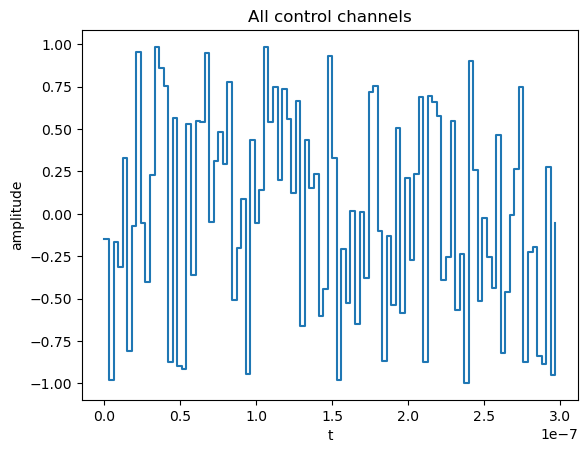

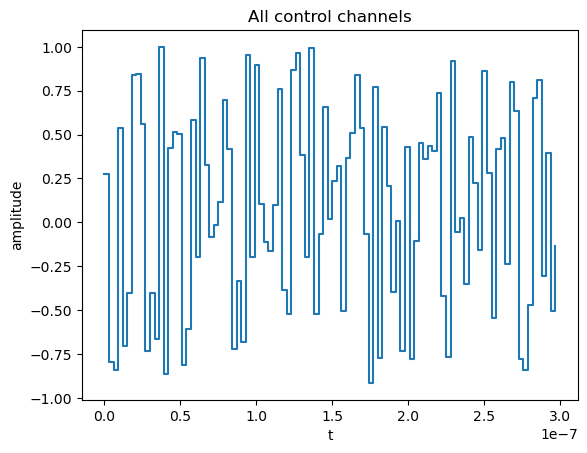

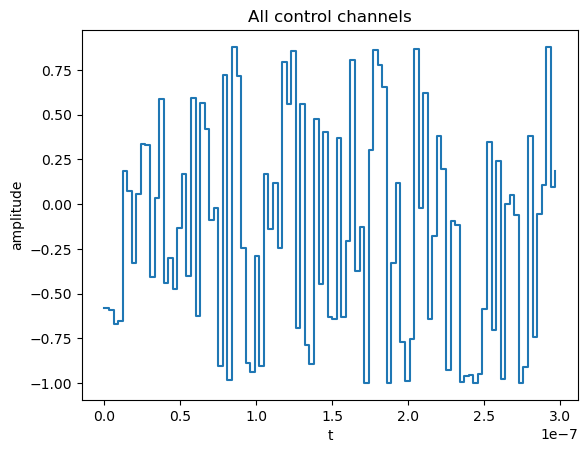

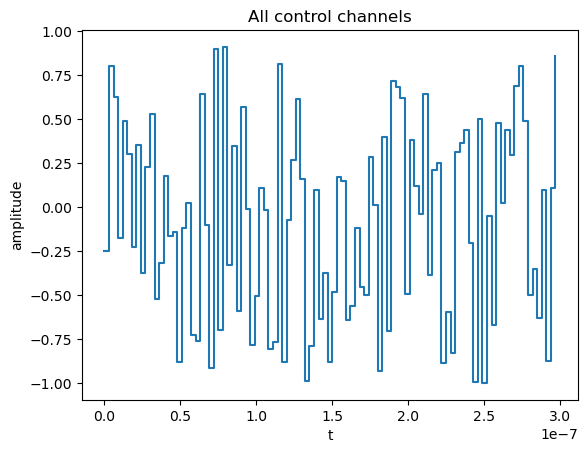

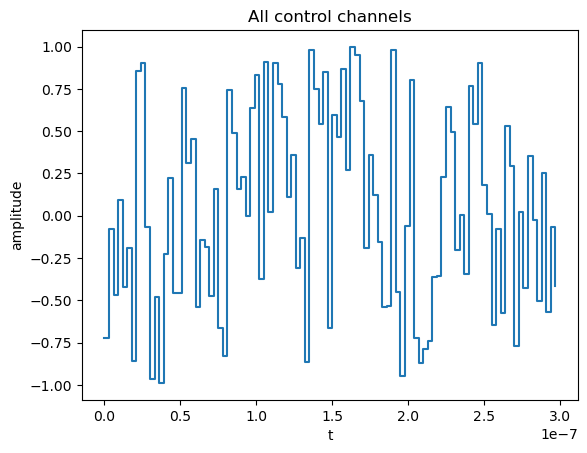

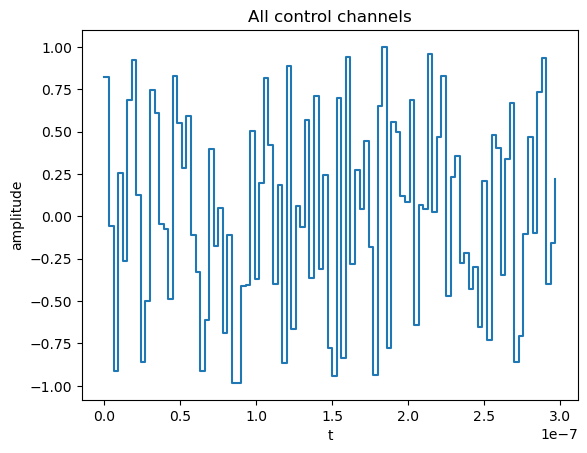

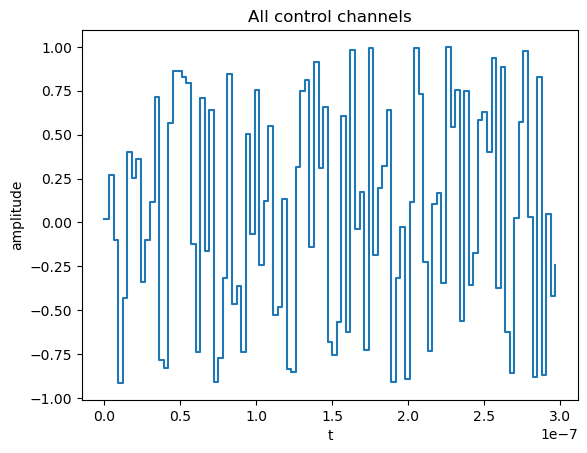

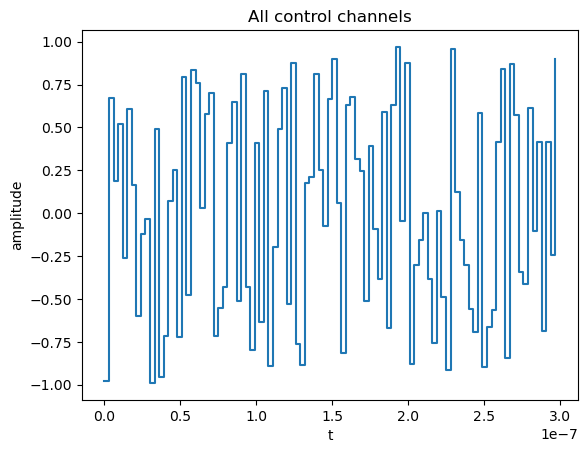

In [110]:
amps = results[0].final_amps
t    = results[0].time


for i in range(np.shape(amps)[1]):
    plt.figure()
    plt.step(t[:-1], amps[:,i], where="post")  # plots all n_ctrls columns
    plt.xlabel("t")
    plt.ylabel("amplitude")
    plt.title("All control channels")
    plt.show()

### Misc Amps

In [36]:
#amps = results[0].final_amps

In [37]:
#np.shape(amps)
#amps_one = amps[:, :2]

In [38]:
#np.shape(amps_one)
#amps = np.column_stack([amps_one[:, 0], amps_one[:, 0],   # Hx0, Hx1
#                     amps_one[:, 1], amps_one[:, 1]])  # Hy0, Hy1
##amps = np.concatenate([amps0, amps1], axis=1)
#np.shape(amps)

In [39]:
#amps = results[1].final_amps
#t    = results[1].time

In [40]:
#plt.figure()
#plt.step(t[:-1], amps[:,:], where="post")  # plots all n_ctrls columns
#plt.xlabel("t")
#plt.ylabel("amplitude")
#plt.title("All control channels")
#plt.show()

In [41]:
#amps0 = results[1].final_amps
#t    = results[1].time

In [42]:
#plt.figure()
#plt.step(t[:-1], amps0[:,0], where="post")  # plots all n_ctrls columns
#plt.xlabel("t")
#plt.ylabel("amplitude")
#plt.title("All control channels")
#plt.show()

In [43]:
#amps1 = results[1].final_amps
#t    = results[1].time

In [44]:
#plt.figure()
#plt.step(t[:-1], amps1[:,0], where="post")  # plots all n_ctrls columns
#plt.xlabel("t")
#plt.ylabel("amplitude")
#plt.title("All control channels")
#plt.show()

In [45]:
#amps_old = results[1].final_amps
#t    = results[1].time

In [46]:
#plt.figure()
#plt.step(t[:-1], amps_old[:,:], where="post")  # plots all n_ctrls columns
#plt.xlabel("t")
#plt.ylabel("amplitude")
#plt.title("All control channels")
#plt.show()

In [47]:
#amps = np.column_stack([amps0[:, 0], amps1[:, 0],   # Hx0, Hx1
#                     amps0[:, 1], amps1[:, 1]])  # Hy0, Hy1
##amps = np.concatenate([amps0, amps1], axis=1)
#np.shape(amps)

In [48]:
## total duration
#T = 2 # assuming microsec
## number of time steps
#detune = 0.01
##det_values = np.linspace(0.0, 20.0, 11)  # 0, 0.5, 1.0, ..., 20.0
#
#fid_values = []
#results = []
#print(f"Running optimisation for detuning = {detune:.3f}...")
#result = run_grape_for_det(detune, v_rho_0, v_rho_target, amps)
#results.append(result)
#fid_values.append(1.0 - result.fid_err)  # final fidelity
#print(f"  final fidelity error = {result.fid_err:.3e}")

In [49]:
#plt.figure()
#plt.step(t[:-1], amps[:,1], where="post")  # plots all n_ctrls columns
#plt.xlabel("t")
#plt.ylabel("amplitude")
#plt.title("All control channels")
#plt.show()

In [50]:
#amps_new = results[0].final_amps
#t    = results[0].time

In [51]:
#plt.figure()
#plt.step(t[:-1], amps_new[:,:], where="post")  # plots all n_ctrls columns
#plt.xlabel("t")
#plt.ylabel("amplitude")
#plt.title("All control channels")
#plt.show()

In [52]:
#result.final_amps.shape

## Using the resulting targets, calculate secret independence

In [54]:
#detuning = 0
#initv = operator_to_vector(Qobj([[0.999,0],[0,0.001]]))  # preparation error 
#
#fid_values = []
#final_states = []
#results = []
#for targ in rho_targets:
#    targv =  operator_to_vector(targ) # target 
#    result = run_grape_for_det(detuning, initv, targv)
#    results.append(result)
#    final_states.append(qutip.vector_to_operator(result.evo_full_final).full())
#    fid_values.append(1.0 - result.fid_err)  # final fidelity
#    print(f"  final fidelity error = {result.fid_err:.3e}")

In [55]:
#target_states = [rho.full() for rho in rho_targets]

In [56]:
#K = len(target_states)
#
## variables
#JE = cp.Variable((4, 4), complex=True, hermitian=True)
#
## P_t, Q_t, for each theta, Hermitian, PSD
#J = cp.Variable((4, 4), complex=True, hermitian=True)
#P = [cp.Variable((2, 2), complex=True, hermitian=True) for _ in range(K)]
#Q = [cp.Variable((2, 2), complex=True, hermitian=True) for _ in range(K)]
#
#constraints = []
#
## CP
#constraints += [J >> 0]
#
## TP: Tr_B(J) = I_A
#J4 = cp.reshape(J, (2, 2, 2, 2))  # (a1,b1,a2,b2)
#Tr_B = cp.sum(J4, axis=1)         # sum over b1 → (a1,a2)
#constraints += [Tr_B == np.eye(2)]
#
#objective_terms = []
#for k in range(K):
#    a_k = target_states[k]   # 2x2 numpy
#    b_k = final_states[k]   # 2x2 numpy
#
#    E_a_k = apply_choi_cp(J, a_k)    # 2x2
#    Delta = E_a_k - b_k
#
#    constraints += [
#        P[k] >> 0,
#        Q[k] >> 0,
#        Delta == P[k] - Q[k],
#    ]
#    objective_terms.append(0.5*cp.trace(P[k] + Q[k])/K)
#
#obj = cp.Minimize(cp.real(cp.sum(objective_terms)))
#prob = cp.Problem(obj, constraints)
#prob.solve(solver=cp.SCS, verbose=True)
#J_opt = np.array(J.value)

In [57]:
#calc_objective(target_states, final_states)

In [58]:
#for res in results:
#    plot_pulse(res)